<a href="https://colab.research.google.com/github/DeepanshuSharma1607/Fake_News_Generator_in_python/blob/main/ipl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [766]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [767]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "IPL_ball_by_ball_updated.csv"

# Load the latest version
df_23= kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "dgsports/ipl-ball-by-ball-2008-to-2022",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

Using Colab cache for faster access to the 'ipl-ball-by-ball-2008-to-2022' dataset.


In [768]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "deliveries_updated_ipl_upto_2025.csv"

# Load the latest version
df_ = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "dgsports/ipl-ball-by-ball-2008-to-2022",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

100%|██████████| 29.7M/29.7M [00:00<00:00, 35.2MB/s]


In [769]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path1 = "ipl_2024_deliveries.csv"
file_path2 = "ipl_2025_deliveries.csv"
file_path3 = "ipl_2026_deliveries.csv"
# Load the latest version
df_24= kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "sahiltailor/ipl-2024-ball-by-ball-dataset",
  file_path1,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)
df_25= kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "sahiltailor/ipl-2024-ball-by-ball-dataset",
  file_path2,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)
df_26= kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "sahiltailor/ipl-2024-ball-by-ball-dataset",
  file_path3,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)



Using Colab cache for faster access to the 'ipl-2024-ball-by-ball-dataset' dataset.
Using Colab cache for faster access to the 'ipl-2024-ball-by-ball-dataset' dataset.


100%|██████████| 199k/199k [00:00<00:00, 1.24MB/s]


In [770]:
df_['season']=pd.to_datetime(df_['date']).dt.year

In [771]:
dv=[df_,df_23,df_24,df_25,df_26]
mapping = {
    'start_date':'date'
}
df_23.rename(columns=mapping, inplace=True)

In [772]:
for df in dv:
  df['date']=pd.to_datetime(df['date'])

In [773]:
team_mapping = {
    # Current name
    'Delhi Capitals': 'DC',
    # Old name → same short code
    'Delhi Daredevils': 'DC',

    'Punjab Kings': 'PBKS',
    'Kings XI Punjab': 'PBKS',

    'Royal Challengers Bangalore': 'RCB',
    'Royal Challengers Bengaluru': 'RCB',

    # Never changed
    'Kolkata Knight Riders': 'KKR',
    'Chennai Super Kings': 'CSK',
    'Rajasthan Royals': 'RR',
    'Mumbai Indians': 'MI',
    'Sunrisers Hyderabad': 'SRH',
    'Lucknow Super Giants': 'LSG',
    'Gujarat Titans': 'GT',

    # Dissolved teams
    'Deccan Chargers': 'DC_OLD',
    'Kochi Tuskers Kerala': 'KTK',
    'Pune Warriors': 'PWI',
    'Rising Pune Supergiants': 'RPS',
    'Rising Pune Supergiant': 'RPS',
    'Gujarat Lions': 'GL',
}


# Apply to both team columns
df_['batting_team'] = df_['batting_team'].replace(team_mapping)
df_['bowling_team'] = df_['bowling_team'].replace(team_mapping)

df_23['batting_team'] = df_23['batting_team'].replace(team_mapping)
df_23['bowling_team'] = df_23['bowling_team'].replace(team_mapping)


In [774]:
venue_sources = [df_23, df_24, df_25, df_26]

venue_lookup = pd.concat([
    df[['date', 'batting_team', 'bowling_team', 'venue']]
    for df in venue_sources
]).drop_duplicates(subset=['date', 'batting_team', 'bowling_team'])

In [775]:
if 'venue' in df_.columns:
    df_ = df_.drop(columns=['venue'])

df_ = df_.merge(
    venue_lookup,
    on=['date', 'batting_team', 'bowling_team'],
    how='left'
)

In [776]:
df_.head(2)

,matchId,inning,over_ball,over,ball,batting_team,bowling_team,batsman,non_striker,bowler,...,isWide,isNoBall,Byes,LegByes,Penalty,dismissal_kind,player_dismissed,date,season,venue
0,335982,1,0.1,0,1,KKR,RCB,SC Ganguly,BB McCullum,P Kumar,...,NaN,NaN,NaN,1.0,NaN,NaN,NaN,2008-04-18,2008,M Chinnaswamy Stadium
1,335982,1,0.2,0,2,KKR,RCB,BB McCullum,SC Ganguly,P Kumar,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2008-04-18,2008,M Chinnaswamy Stadium


In [777]:
df_=df_.drop(columns=["over","ball"])

In [778]:
df_=df_.drop(columns=["date","Penalty","non_striker"])

In [779]:
df_26=df_26.drop(columns=["date",'match_no',"phase","fielder"])

In [780]:
print(df_.shape)
print(df_26.shape)

(278205, 17)
(1382, 17)


In [781]:
df_.columns

Index(['matchId', 'inning', 'over_ball', 'batting_team', 'bowling_team',
       'batsman', 'bowler', 'batsman_runs', 'extras', 'isWide', 'isNoBall',
       'Byes', 'LegByes', 'dismissal_kind', 'player_dismissed', 'season',
       'venue'],
      dtype='object')

In [782]:
mapping = {
    "innings":"inning",
}
df_26.rename(columns=mapping, inplace=True)
df_26.columns

Index(['match_id', 'season', 'venue', 'batting_team', 'bowling_team', 'inning',
       'over', 'striker', 'bowler', 'runs_of_bat', 'extras', 'wide', 'legbyes',
       'byes', 'noballs', 'wicket_type', 'player_dismissed'],
      dtype='object')

In [783]:
#Rename columns
mapping = {
    'matchId':'match_id',
    'over_ball':'over',
    'batsman':'striker',
    'isWide':'wide',
    'isNoBall':'noballs',
    "batsman_runs":"runs_of_bat",
    "dismissal_kind":"wicket_type",
    "LegByes":"legbyes",
    "Byes":"byes"

}
df_.rename(columns=mapping, inplace=True)

In [784]:
df_['venue'] = (df_['venue']
             .str.split(',').str[0]
             .str.strip()
             .str.lower()
             .str.replace(' ', '_'))
df_26['venue'] = (df_26['venue']
             .str.split(',').str[0]
             .str.strip()
             .str.lower()
             .str.replace(' ', '_'))


In [785]:
df = pd.concat([df_, df_26])
print(df.shape)
display(df.head())

(279587, 17)


,match_id,inning,over,batting_team,bowling_team,striker,bowler,runs_of_bat,extras,wide,noballs,byes,legbyes,wicket_type,player_dismissed,season,venue
0,335982,1,0.1,KKR,RCB,SC Ganguly,P Kumar,0,1,NaN,NaN,NaN,1.0,NaN,NaN,2008,m_chinnaswamy_stadium
1,335982,1,0.2,KKR,RCB,BB McCullum,P Kumar,0,0,NaN,NaN,NaN,NaN,NaN,NaN,2008,m_chinnaswamy_stadium
2,335982,1,0.3,KKR,RCB,BB McCullum,P Kumar,0,1,1.0,NaN,NaN,NaN,NaN,NaN,2008,m_chinnaswamy_stadium
3,335982,1,0.4,KKR,RCB,BB McCullum,P Kumar,0,0,NaN,NaN,NaN,NaN,NaN,NaN,2008,m_chinnaswamy_stadium
4,335982,1,0.5,KKR,RCB,BB McCullum,P Kumar,0,0,NaN,NaN,NaN,NaN,NaN,NaN,2008,m_chinnaswamy_stadium


In [786]:
df.isnull().sum()

,0
match_id,0
inning,0
over,0
batting_team,0
bowling_team,0
striker,0
bowler,0
runs_of_bat,0
extras,0
wide,269125


In [787]:
df['bowling_team'].nunique()

15

In [788]:
df.columns

Index(['match_id', 'inning', 'over', 'batting_team', 'bowling_team', 'striker',
       'bowler', 'runs_of_bat', 'extras', 'wide', 'noballs', 'byes', 'legbyes',
       'wicket_type', 'player_dismissed', 'season', 'venue'],
      dtype='object')

In [789]:
print(df[['runs_of_bat', 'extras', 'wide',
       'noballs', 'byes', 'legbyes', 'wicket_type', 'player_dismissed']])

      runs_of_bat  extras  wide  noballs  byes  legbyes wicket_type  \
0               0       1   NaN      NaN   NaN      1.0         NaN   
1               0       0   NaN      NaN   NaN      NaN         NaN   
2               0       1   1.0      NaN   NaN      NaN         NaN   
3               0       0   NaN      NaN   NaN      NaN         NaN   
4               0       0   NaN      NaN   NaN      NaN         NaN   
...           ...     ...   ...      ...   ...      ...         ...   
1377            1       0   0.0      0.0   0.0      0.0         NaN   
1378            0       0   0.0      0.0   0.0      0.0         NaN   
1379            1       0   0.0      0.0   0.0      0.0         NaN   
1380            0       0   0.0      0.0   0.0      0.0      caught   
1381            0       0   0.0      0.0   0.0      0.0      bowled   

         player_dismissed  
0                     NaN  
1                     NaN  
2                     NaN  
3                     NaN  
4      

In [790]:
cols_to_fix = ['runs_of_bat', 'extras', 'wide', 'noballs', 'byes', 'legbyes']
df[cols_to_fix] = df[cols_to_fix].fillna(0)

df['curr_ball_runs'] = df['runs_of_bat'] + df['extras']
total_score = df.groupby(['match_id', 'inning', 'batting_team'])['curr_ball_runs'].cumsum().reset_index()


In [791]:
df['team_runs'] = df.groupby(['match_id','batting_team'])['curr_ball_runs'].cumsum()
df['team_runs'] = df.groupby(['match_id','batting_team'])['team_runs'].shift(1).fillna(0)

In [792]:
df['first_innings_runs'] = np.where(df['inning'] == 1, df['team_runs'], 0)

df['second_innings_runs'] = np.where(df['inning'] == 2, df['team_runs'], 0)

In [793]:
df

,match_id,inning,over,batting_team,bowling_team,striker,bowler,runs_of_bat,extras,wide,...,byes,legbyes,wicket_type,player_dismissed,season,venue,curr_ball_runs,team_runs,first_innings_runs,second_innings_runs
0,335982,1,0.1,KKR,RCB,SC Ganguly,P Kumar,0,1,0.0,...,0.0,1.0,NaN,NaN,2008,m_chinnaswamy_stadium,1,0.0,0.0,0.0
1,335982,1,0.2,KKR,RCB,BB McCullum,P Kumar,0,0,0.0,...,0.0,0.0,NaN,NaN,2008,m_chinnaswamy_stadium,0,1.0,1.0,0.0
2,335982,1,0.3,KKR,RCB,BB McCullum,P Kumar,0,1,1.0,...,0.0,0.0,NaN,NaN,2008,m_chinnaswamy_stadium,1,1.0,1.0,0.0
3,335982,1,0.4,KKR,RCB,BB McCullum,P Kumar,0,0,0.0,...,0.0,0.0,NaN,NaN,2008,m_chinnaswamy_stadium,0,2.0,2.0,0.0
4,335982,1,0.5,KKR,RCB,BB McCullum,P Kumar,0,0,0.0,...,0.0,0.0,NaN,NaN,2008,m_chinnaswamy_stadium,0,2.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1377,202606,2,15.2,KKR,SRH,Kartik Tyagi,Jaydev Unadkat,1,0,0.0,...,0.0,0.0,NaN,NaN,2026,eden_gardens,1,158.0,0.0,158.0
1378,202606,2,15.3,KKR,SRH,Vaibhav Arora,Jaydev Unadkat,0,0,0.0,...,0.0,0.0,NaN,NaN,2026,eden_gardens,0,159.0,0.0,159.0
1379,202606,2,15.4,KKR,SRH,Vaibhav Arora,Jaydev Unadkat,1,0,0.0,...,0.0,0.0,NaN,NaN,2026,eden_gardens,1,159.0,0.0,159.0
1380,202606,2,15.5,KKR,SRH,Kartik Tyagi,Jaydev Unadkat,0,0,0.0,...,0.0,0.0,caught,Kartik Tyagi,2026,eden_gardens,0,160.0,0.0,160.0


In [794]:
df['is_wicket']=df['player_dismissed'].notna().astype(int)

In [795]:
df.columns

Index(['match_id', 'inning', 'over', 'batting_team', 'bowling_team', 'striker',
       'bowler', 'runs_of_bat', 'extras', 'wide', 'noballs', 'byes', 'legbyes',
       'wicket_type', 'player_dismissed', 'season', 'venue', 'curr_ball_runs',
       'team_runs', 'first_innings_runs', 'second_innings_runs', 'is_wicket'],
      dtype='object')

In [796]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 279587 entries, 0 to 1381
Data columns (total 22 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   match_id             279587 non-null  int64  
 1   inning               279587 non-null  int64  
 2   over                 279587 non-null  float64
 3   batting_team         279587 non-null  object 
 4   bowling_team         279587 non-null  object 
 5   striker              279587 non-null  object 
 6   bowler               279587 non-null  object 
 7   runs_of_bat          279587 non-null  int64  
 8   extras               279587 non-null  int64  
 9   wide                 279587 non-null  float64
 10  noballs              279587 non-null  float64
 11  byes                 279587 non-null  float64
 12  legbyes              279587 non-null  float64
 13  wicket_type          13904 non-null   object 
 14  player_dismissed     13901 non-null   object 
 15  season               279

In [797]:
df

,match_id,inning,over,batting_team,bowling_team,striker,bowler,runs_of_bat,extras,wide,...,legbyes,wicket_type,player_dismissed,season,venue,curr_ball_runs,team_runs,first_innings_runs,second_innings_runs,is_wicket
0,335982,1,0.1,KKR,RCB,SC Ganguly,P Kumar,0,1,0.0,...,1.0,NaN,NaN,2008,m_chinnaswamy_stadium,1,0.0,0.0,0.0,0
1,335982,1,0.2,KKR,RCB,BB McCullum,P Kumar,0,0,0.0,...,0.0,NaN,NaN,2008,m_chinnaswamy_stadium,0,1.0,1.0,0.0,0
2,335982,1,0.3,KKR,RCB,BB McCullum,P Kumar,0,1,1.0,...,0.0,NaN,NaN,2008,m_chinnaswamy_stadium,1,1.0,1.0,0.0,0
3,335982,1,0.4,KKR,RCB,BB McCullum,P Kumar,0,0,0.0,...,0.0,NaN,NaN,2008,m_chinnaswamy_stadium,0,2.0,2.0,0.0,0
4,335982,1,0.5,KKR,RCB,BB McCullum,P Kumar,0,0,0.0,...,0.0,NaN,NaN,2008,m_chinnaswamy_stadium,0,2.0,2.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1377,202606,2,15.2,KKR,SRH,Kartik Tyagi,Jaydev Unadkat,1,0,0.0,...,0.0,NaN,NaN,2026,eden_gardens,1,158.0,0.0,158.0,0
1378,202606,2,15.3,KKR,SRH,Vaibhav Arora,Jaydev Unadkat,0,0,0.0,...,0.0,NaN,NaN,2026,eden_gardens,0,159.0,0.0,159.0,0
1379,202606,2,15.4,KKR,SRH,Vaibhav Arora,Jaydev Unadkat,1,0,0.0,...,0.0,NaN,NaN,2026,eden_gardens,1,159.0,0.0,159.0,0
1380,202606,2,15.5,KKR,SRH,Kartik Tyagi,Jaydev Unadkat,0,0,0.0,...,0.0,caught,Kartik Tyagi,2026,eden_gardens,0,160.0,0.0,160.0,1


In [798]:
final_scores = df[df['inning'] == 1].groupby('match_id')['team_runs'].max()
df = df.merge(final_scores.rename('target'), on='match_id')
df['target'] = np.where(df['inning'] == 2, df['target'] + 1, 0)

In [799]:
df['over_'] = df['over'].astype(str).str.split('.').str[0].astype(int)
df['ball_in_over'] = (df['over'].astype(str)
                      .str.split('.')
                      .str[1]
                      .fillna(0)
                      .astype(int))

In [800]:
df['ball_in_over'] = df['ball_in_over'].clip(upper=6)
df['balls_bowled'] = df['over_'] * 6 + df['ball_in_over']

In [801]:
df['runs_to_win'] = np.where(
    df['inning'] == 2,
    df['target'] - df['team_runs'],
    0
)

In [802]:
balls_remaining = (120 - df['balls_bowled']).clip(lower=0)


In [803]:
df['curr_run_rate'] = np.where(
    df['balls_bowled'] == 0, 0,
    (df['team_runs'] * 6) / df['balls_bowled']
)

In [804]:
df['req_run_rate'] = np.where(
    balls_remaining == 0,
    np.inf,
    (df['runs_to_win'] * 6) / balls_remaining
)
df['req_run_rate'] = df['req_run_rate'].clip(0, 36)


In [805]:
df['req_run_rate'] = df['req_run_rate'].replace(np.inf, 100)

In [806]:
df['crr_rrr_ratio'] = df['curr_run_rate'] / df['req_run_rate'].replace(0, np.inf)

df['crr_rrr_ratio'] = df['crr_rrr_ratio'].clip(0, 10)

df.loc[df['inning'] == 1,
       ['target', 'runs_to_win', 'req_run_rate', 'crr_rrr_ratio']] = 0

In [807]:
df['balls_remaining'] = (20 * 6) - df['balls_bowled'].clip(lower=0)

In [808]:
df['total_wickets'] = df.groupby(['match_id','inning'])['is_wicket'].cumsum()
df['total_wickets'] = df.groupby(['match_id','inning'])['total_wickets'].shift(1).fillna(0)
df['wickets_remaining'] = 10 - df['total_wickets']

In [809]:
df

,match_id,inning,over,batting_team,bowling_team,striker,bowler,runs_of_bat,extras,wide,...,over_,ball_in_over,balls_bowled,runs_to_win,curr_run_rate,req_run_rate,crr_rrr_ratio,balls_remaining,total_wickets,wickets_remaining
0,335982,1,0.1,KKR,RCB,SC Ganguly,P Kumar,0,1,0.0,...,0,1,1,0.0,0.000000,0.000000,0.000000,119,0.0,10.0
1,335982,1,0.2,KKR,RCB,BB McCullum,P Kumar,0,0,0.0,...,0,2,2,0.0,3.000000,0.000000,0.000000,118,0.0,10.0
2,335982,1,0.3,KKR,RCB,BB McCullum,P Kumar,0,1,1.0,...,0,3,3,0.0,2.000000,0.000000,0.000000,117,0.0,10.0
3,335982,1,0.4,KKR,RCB,BB McCullum,P Kumar,0,0,0.0,...,0,4,4,0.0,3.000000,0.000000,0.000000,116,0.0,10.0
4,335982,1,0.5,KKR,RCB,BB McCullum,P Kumar,0,0,0.0,...,0,5,5,0.0,2.400000,0.000000,0.000000,115,0.0,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279582,202606,2,15.2,KKR,SRH,Kartik Tyagi,Jaydev Unadkat,1,0,0.0,...,15,2,92,69.0,10.304348,14.785714,0.696912,28,8.0,2.0
279583,202606,2,15.3,KKR,SRH,Vaibhav Arora,Jaydev Unadkat,0,0,0.0,...,15,3,93,68.0,10.258065,15.111111,0.678843,27,8.0,2.0
279584,202606,2,15.4,KKR,SRH,Vaibhav Arora,Jaydev Unadkat,1,0,0.0,...,15,4,94,68.0,10.148936,15.692308,0.646746,26,8.0,2.0
279585,202606,2,15.5,KKR,SRH,Kartik Tyagi,Jaydev Unadkat,0,0,0.0,...,15,5,95,67.0,10.105263,16.080000,0.628437,25,8.0,2.0


In [810]:
df.columns

Index(['match_id', 'inning', 'over', 'batting_team', 'bowling_team', 'striker',
       'bowler', 'runs_of_bat', 'extras', 'wide', 'noballs', 'byes', 'legbyes',
       'wicket_type', 'player_dismissed', 'season', 'venue', 'curr_ball_runs',
       'team_runs', 'first_innings_runs', 'second_innings_runs', 'is_wicket',
       'target', 'over_', 'ball_in_over', 'balls_bowled', 'runs_to_win',
       'curr_run_rate', 'req_run_rate', 'crr_rrr_ratio', 'balls_remaining',
       'total_wickets', 'wickets_remaining'],
      dtype='object')

In [811]:
df['is_out'] = (df['player_dismissed'] == df['striker']).astype(int)

df['valid_ball'] = (df['wide'] == 0).astype(int)

# df['batsman_run_cum'] = df.groupby(['match_id','striker'])['runs_off_bat'].cumsum()
# df['batsman_run_cum'] = df.groupby(['match_id','striker'])['batsman_run_cum'].shift(1).fillna(0)

# df['balls_faced_cum'] = df.groupby(['match_id','striker'])['valid_ball'].cumsum()
# df['balls_faced_cum'] = df.groupby(['match_id','striker'])['balls_faced_cum'].shift(1).fillna(0)

# df['match_strike_rate'] = np.where(
#     df['balls_faced_cum'] == 0,
#     0,
#     (df['batsman_run_cum'] / df['balls_faced_cum']) * 100
# )



# df['batsman_run_cum_career'] = df.groupby('striker')['runs_off_bat'].cumsum()
# df['batsman_run_cum_career'] = df.groupby('striker')['batsman_run_cum_career'].shift(1).fillna(0)

# df['balls_faced_cum_career'] = df.groupby('striker')['valid_ball'].cumsum()
# df['balls_faced_cum_career'] = df.groupby('striker')['balls_faced_cum_career'].shift(1).fillna(0)

# df['batsman_outs_career'] = df.groupby('striker')['is_out'].cumsum()
# df['batsman_outs_career'] = df.groupby('striker')['batsman_outs_career'].shift(1).fillna(0)

# universal_runs = 50
# universal_outs = 2

# df['batting_average'] = (
#     df['batsman_run_cum_career'] + universal_runs
# ) / (
#     df['batsman_outs_career'] + universal_outs
# )


# universal_sr_runs = 100
# universal_balls = 80

# df['career_strike_rate'] = (
#     (df['batsman_run_cum_career'] + universal_sr_runs) /
#     (df['balls_faced_cum_career'] + universal_balls)
# ) * 100
# Aggregate per striker per season
season_bat = df.groupby(['season', 'striker']).agg(
    season_runs=('runs_of_bat', 'sum'),
    season_balls=('valid_ball', 'sum'),
    season_outs=('is_out', 'sum')
).reset_index().sort_values(['striker', 'season'])

# Cumsum then shift — so current season stats NOT included
season_bat['career_runs'] = season_bat.groupby('striker')['season_runs'].cumsum().shift(1).fillna(0)
season_bat['career_balls'] = season_bat.groupby('striker')['season_balls'].cumsum().shift(1).fillna(0)
season_bat['career_outs'] = season_bat.groupby('striker')['season_outs'].cumsum().shift(1).fillna(0)

# Smoothed stats
season_bat['batting_average'] = (season_bat['career_runs'] + 50) / (season_bat['career_outs'] + 2)
season_bat['career_strike_rate'] = ((season_bat['career_runs'] + 100) / (season_bat['career_balls'] + 80)) * 100

# Merge back
df = df.merge(
    season_bat[['season', 'striker', 'batting_average', 'career_strike_rate']],
    on=['season', 'striker'], how='left'
)

In [812]:


# df['bowler_runs_conceded'] = df.groupby('bowler')['runs_off_bat'].cumsum()
# df['bowler_runs_conceded'] = df.groupby('bowler')['bowler_runs_conceded'].shift(1).fillna(0)

# df['bowler_balls_bowled'] = df.groupby('bowler')['valid_ball'].cumsum()
# df['bowler_balls_bowled'] = df.groupby('bowler')['bowler_balls_bowled'].shift(1).fillna(0)

# df['bowler_wickets_cum'] = df.groupby('bowler')['is_wicket'].cumsum()
# df['bowler_wickets_cum'] = df.groupby('bowler')['bowler_wickets_cum'].shift(1).fillna(0)



# universal_runs_conceded = 300
# universal_balls = 240
# universal_wickets = 10


# df['exp_bowler_eco'] = (
#     (df['bowler_runs_conceded'] + universal_runs_conceded) /
#     (df['bowler_balls_bowled'] + universal_balls)
# ) * 6


# df['exp_bowler_avg'] = (
#     df['bowler_runs_conceded'] + universal_runs_conceded
# ) / (
#     df['bowler_wickets_cum'] + universal_wickets
# )
# Aggregate per bowler per season
season_bowl = df.groupby(['season', 'bowler']).agg(
    season_runs_c=('runs_of_bat', 'sum'),
    season_balls_b=('valid_ball', 'sum'),
    season_wkts=('is_wicket', 'sum')
).reset_index().sort_values(['bowler', 'season'])

# Cumsum then shift — so current season NOT included
season_bowl['career_runs_c'] = season_bowl.groupby('bowler')['season_runs_c'].cumsum().shift(1).fillna(0)
season_bowl['career_balls_b'] = season_bowl.groupby('bowler')['season_balls_b'].cumsum().shift(1).fillna(0)
season_bowl['career_wkts'] = season_bowl.groupby('bowler')['season_wkts'].cumsum().shift(1).fillna(0)

# Smoothed stats
season_bowl['exp_bowler_eco'] = ((season_bowl['career_runs_c'] + 300) / (season_bowl['career_balls_b'] + 240)) * 6
season_bowl['exp_bowler_avg'] = (season_bowl['career_runs_c'] + 300) / (season_bowl['career_wkts'] + 10)

# Merge back
df = df.merge(
    season_bowl[['season', 'bowler', 'exp_bowler_eco', 'exp_bowler_avg']],
    on=['season', 'bowler'], how='left'
)

In [813]:
df.columns

Index(['match_id', 'inning', 'over', 'batting_team', 'bowling_team', 'striker',
       'bowler', 'runs_of_bat', 'extras', 'wide', 'noballs', 'byes', 'legbyes',
       'wicket_type', 'player_dismissed', 'season', 'venue', 'curr_ball_runs',
       'team_runs', 'first_innings_runs', 'second_innings_runs', 'is_wicket',
       'target', 'over_', 'ball_in_over', 'balls_bowled', 'runs_to_win',
       'curr_run_rate', 'req_run_rate', 'crr_rrr_ratio', 'balls_remaining',
       'total_wickets', 'wickets_remaining', 'is_out', 'valid_ball',
       'batting_average', 'career_strike_rate', 'exp_bowler_eco',
       'exp_bowler_avg'],
      dtype='object')

In [814]:
df.shape

(279587, 39)

In [815]:
final_scores = df.groupby(['match_id', 'inning'])['team_runs'].max().reset_index()
final_scores = final_scores.pivot(index='match_id', columns='inning', values='team_runs').reset_index()
final_scores['winner_innings'] = np.where(
    final_scores[2] > final_scores[1], 2,
    np.where(final_scores[2] < final_scores[1], 1, 0)
)

df = df.merge(final_scores[['match_id', 'winner_innings']], on='match_id', how='left')

df['result'] = np.where(
    (df['inning'] == 2) & (df['winner_innings'] == 2),
    1,
    np.where(
        (df['inning'] == 2) & (df['winner_innings'] == 1),
        0,
        -1   # tie
    )
)

In [816]:
df['match_phase'] = pd.cut(df['over_'],
                            bins=[-1, 5, 14, 19],
                            labels=[0, 1, 2]).astype(int)

In [817]:
df['first_innings_total'] = df['target'] - 1

In [818]:
df.shape

(279587, 43)

In [819]:
df.columns

Index(['match_id', 'inning', 'over', 'batting_team', 'bowling_team', 'striker',
       'bowler', 'runs_of_bat', 'extras', 'wide', 'noballs', 'byes', 'legbyes',
       'wicket_type', 'player_dismissed', 'season', 'venue', 'curr_ball_runs',
       'team_runs', 'first_innings_runs', 'second_innings_runs', 'is_wicket',
       'target', 'over_', 'ball_in_over', 'balls_bowled', 'runs_to_win',
       'curr_run_rate', 'req_run_rate', 'crr_rrr_ratio', 'balls_remaining',
       'total_wickets', 'wickets_remaining', 'is_out', 'valid_ball',
       'batting_average', 'career_strike_rate', 'exp_bowler_eco',
       'exp_bowler_avg', 'winner_innings', 'result', 'match_phase',
       'first_innings_total'],
      dtype='object')

In [820]:
drop_list = ['match_id',
     'runs_of_bat', 'extras', 'wide',
    'noballs', 'byes', 'legbyes',  'curr_ball_runs',
    'wicket_type', 'player_dismissed',  'is_wicket', 'is_out', 'winner_innings',
    'over', 'over_', 'ball_in_over', 'balls_bowled', 'valid_ball',
    'team_runs', 'first_innings_runs', 'second_innings_runs', 'target',
    # 'batsman_run_cum', 'balls_faced_cum',
    'total_wickets'
]
df = df.drop(columns=drop_list)

In [821]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279587 entries, 0 to 279586
Data columns (total 20 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   inning               279587 non-null  int64  
 1   batting_team         279587 non-null  object 
 2   bowling_team         279587 non-null  object 
 3   striker              279587 non-null  object 
 4   bowler               279587 non-null  object 
 5   season               279587 non-null  int64  
 6   venue                279587 non-null  object 
 7   runs_to_win          279587 non-null  float64
 8   curr_run_rate        279587 non-null  float64
 9   req_run_rate         279587 non-null  float64
 10  crr_rrr_ratio        279587 non-null  float64
 11  balls_remaining      279587 non-null  int64  
 12  wickets_remaining    279587 non-null  float64
 13  batting_average      279587 non-null  float64
 14  career_strike_rate   279587 non-null  float64
 15  exp_bowler_eco   

In [822]:
df['pressure'] = df['req_run_rate'] - df['curr_run_rate']

In [823]:
df['inning'].unique()

array([1, 2, 3, 4, 5, 6])

In [824]:
df = df[df['inning'] <= 2]
df = df[df['result'] != -1]


In [825]:
df.describe()

,inning,season,runs_to_win,curr_run_rate,req_run_rate,crr_rrr_ratio,balls_remaining,wickets_remaining,batting_average,career_strike_rate,exp_bowler_eco,exp_bowler_avg,result,match_phase,first_innings_total,pressure
count,118948.0,118948.000000,118948.000000,118948.000000,118948.000000,118948.000000,118948.000000,118948.000000,118948.000000,118948.000000,118948.000000,118948.000000,118948.000000,118948.000000,118948.000000,118948.000000
mean,2.0,2016.805007,96.427279,7.365233,10.497059,0.916987,62.673034,7.487658,27.990348,129.719408,7.576274,26.831533,0.274036,0.884782,169.634227,3.131826
std,0.0,5.260532,51.413062,2.365627,5.922369,0.904601,33.497982,2.178139,8.533226,12.829069,0.533086,4.950544,0.446029,0.719754,30.950901,6.366110
min,2.0,2008.000000,-15.000000,0.000000,0.000000,0.000000,0.000000,1.000000,5.428571,82.530120,5.914198,14.846154,0.000000,0.000000,61.000000,-17.582609
25%,2.0,2012.000000,56.000000,6.200000,7.520000,0.526119,34.000000,6.000000,22.363636,121.806167,7.266833,23.186047,0.000000,0.000000,149.000000,-0.401880
50%,2.0,2017.000000,95.000000,7.500000,9.263158,0.759870,63.000000,8.000000,28.000000,128.485964,7.601918,26.142857,0.000000,1.000000,169.000000,2.219843
75%,2.0,2022.000000,134.000000,8.777778,11.547170,1.042835,92.000000,9.000000,32.928571,136.785714,7.922099,30.090909,1.000000,1.000000,189.000000,5.306667
max,2.0,2026.000000,286.000000,24.000000,36.000000,10.000000,119.000000,10.000000,67.333333,194.570136,9.425287,45.312500,1.000000,2.000000,285.000000,31.565217


In [826]:
df = df[df['inning'] == 2]
df = df[df['runs_to_win'] >= 0]
df = df[df['balls_remaining'] > 0]

In [827]:
df.describe()

,inning,season,runs_to_win,curr_run_rate,req_run_rate,crr_rrr_ratio,balls_remaining,wickets_remaining,batting_average,career_strike_rate,exp_bowler_eco,exp_bowler_avg,result,match_phase,first_innings_total,pressure
count,118010.0,118010.000000,118010.000000,118010.000000,118010.000000,118010.000000,118010.000000,118010.000000,118010.000000,118010.000000,118010.000000,118010.000000,118010.000000,118010.000000,118010.000000,118010.000000
mean,2.0,2016.805398,97.101941,7.357271,10.405391,0.923187,63.131345,7.513270,28.024239,129.747427,7.575376,26.830011,0.272604,0.876299,169.628743,3.048120
std,0.0,5.261455,51.028299,2.370056,5.642818,0.905445,33.219315,2.158051,8.524040,12.818901,0.533402,4.951331,0.445301,0.716013,30.951359,6.114806
min,2.0,2008.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,5.428571,82.530120,5.914198,14.846154,0.000000,0.000000,61.000000,-17.582609
25%,2.0,2012.000000,57.000000,6.187500,7.529412,0.532174,35.000000,6.000000,22.465909,121.807229,7.266776,23.186047,0.000000,0.000000,149.000000,-0.391304
50%,2.0,2017.000000,96.000000,7.481481,9.257143,0.763636,64.000000,8.000000,28.026443,128.511967,7.601918,26.142857,0.000000,1.000000,169.000000,2.211429
75%,2.0,2022.000000,135.000000,8.769231,11.505882,1.045977,92.000000,9.000000,32.928571,136.785714,7.922099,30.090909,1.000000,1.000000,189.000000,5.257172
max,2.0,2026.000000,286.000000,24.000000,36.000000,10.000000,119.000000,10.000000,67.333333,194.570136,9.425287,45.312500,1.000000,2.000000,285.000000,31.565217


In [828]:
df = df.sort_values(['season'])
train_df = df[df['season'] <= 2023]
test_df  = df[(df['season'] >= 2024) & (df['season'] <= 2025)]
x_train = train_df.drop(columns=['result', 'inning'])
y_train = train_df['result']
x_test = test_df.drop(columns=['result', 'inning'])
y_test = test_df['result']
print(f"Train: {len(x_train):,} rows | Test: {len(x_test):,} rows")
print(f"Train win%: {y_train.mean():.3f} | Test win%: {y_test.mean():.3f}")

Train: 102,579 rows | Test: 15,114 rows
Train win%: 0.273 | Test win%: 0.273


In [844]:
nominal_cols     = ['batting_team', 'bowling_team','venue']
# categorical_cols = ['venue']
numeric_cols     = [
    'runs_to_win', 'curr_run_rate', 'req_run_rate',
    'balls_remaining', 'wickets_remaining', 'match_phase',
    'batting_average', 'career_strike_rate', 'first_innings_total',
    'exp_bowler_eco', 'exp_bowler_avg', 'season'
]

print("Inf values in numeric cols:", np.isinf(df[numeric_cols]).values.sum())

Inf values in numeric cols: 0


In [852]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, TargetEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, log_loss, brier_score_loss
)
from xgboost import XGBClassifier

def build_preprocessor():
    return ColumnTransformer(transformers=[
        ('nominal',     OneHotEncoder(sparse_output=False, drop='first',
                                      handle_unknown='ignore'), nominal_cols),
        # ('categorical', TargetEncoder(cv=5,smooth='auto'),categorical_cols),
        ('numeric',     StandardScaler(),numeric_cols),
    ])

pipe = make_pipeline(
    build_preprocessor(),
    LogisticRegression(C=0.001, solver='liblinear', max_iter=1000)
)

xgb_pipe = make_pipeline(
    build_preprocessor(),
XGBClassifier(
    n_estimators=300,
    max_depth=4,            # ↑ from 2
    learning_rate=0.05,
    subsample=0.8,          # ↑ from 0.6
    colsample_bytree=0.8,   # ↑ from 0.6
    reg_lambda=5,           # ↓ from 10
    reg_alpha=0,            # ↓ from 2
    min_child_weight=3,     # ↓ from 20 (CRITICAL)
    gamma=0,                # ↓ from 2
    random_state=42
)
)

In [853]:
seasons      = sorted(train_df['season'].unique())
cv_scores_lr  = []
cv_scores_xgb = []

print(f"\n{'Season':<18} {'LR Acc':>7} {'LR AUC':>7}  {'XGB Acc':>8} {'XGB AUC':>8}")
print("─" * 57)

for i in range(5, len(seasons)):
    train_seasons = seasons[:i]
    val_season    = seasons[i]

    X_tr  = train_df[train_df['season'].isin(train_seasons)].drop(columns=['result', 'inning'])
    y_tr  = train_df[train_df['season'].isin(train_seasons)]['result']
    X_val = train_df[train_df['season'] == val_season].drop(columns=['result', 'inning'])
    y_val = train_df[train_df['season'] == val_season]['result']

    # LR
    pipe.fit(X_tr, y_tr)
    lr_acc = accuracy_score(y_val, pipe.predict(X_val))
    lr_auc = roc_auc_score(y_val, pipe.predict_proba(X_val)[:, 1])
    cv_scores_lr.append((lr_acc, lr_auc))

    # XGB
    xgb_pipe.fit(X_tr, y_tr)
    xgb_acc = accuracy_score(y_val, xgb_pipe.predict(X_val))
    xgb_auc = roc_auc_score(y_val, xgb_pipe.predict_proba(X_val)[:, 1])
    cv_scores_xgb.append((xgb_acc, xgb_auc))

    print(f"{train_seasons[-1]} → {val_season:<8} {lr_acc:>7.3f} {lr_auc:>7.3f}  {xgb_acc:>8.3f} {xgb_auc:>8.3f}")


Season              LR Acc  LR AUC   XGB Acc  XGB AUC
─────────────────────────────────────────────────────────


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1, 2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


2012 → 2013       0.742   0.766     0.724    0.755


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


2013 → 2014       0.743   0.755     0.754    0.765
2014 → 2015       0.723   0.801     0.665    0.731


...

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


2021 → 2022       0.824   0.800     0.824    0.769


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


2022 → 2023       0.789   0.761     0.787    0.762


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [854]:
lr_cv  = np.mean(cv_scores_lr,  axis=0)
xgb_cv = np.mean(cv_scores_xgb, axis=0)
print("─" * 57)
print(f"{'CV Mean':<18} {lr_cv[0]:>7.3f} {lr_cv[1]:>7.3f}  {xgb_cv[0]:>8.3f} {xgb_cv[1]:>8.3f}")

─────────────────────────────────────────────────────────
CV Mean              0.733   0.753     0.696    0.703


In [855]:
pipe.fit(x_train, y_train)
xgb_pipe.fit(x_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('nominal',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['batting_team',
                                                   'bowling_team', 'venue']),
                                                 ('numeric', StandardScaler(),
                                                  ['runs_to_win',
                                                   'curr_run_rate',
                                                   'req_run_rate',
                                                   'balls_remaining',
                                                   'wickets_remaining',
                                                   'match_phase',
                                                   'batting_average',
                                                   'career_strik...
                               feature_types=None, feature_weights=None,
                               gamma=0, grow_policy=None, importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None, min_child_weight=3,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=300,
                               n_jobs=None, num_parallel_tree=None, ...))])

In [856]:
lr_train_prob  = pipe.predict_proba(x_train)[:, 1]
lr_test_prob   = pipe.predict_proba(x_test)[:, 1]
lr_train_pred  = pipe.predict(x_train)
lr_test_pred   = pipe.predict(x_test)

xgb_train_prob = xgb_pipe.predict_proba(x_train)[:, 1]
xgb_test_prob  = xgb_pipe.predict_proba(x_test)[:, 1]
xgb_train_pred = xgb_pipe.predict(x_train)
xgb_test_pred  = xgb_pipe.predict(x_test)

ens_test_prob  = 0.65 * xgb_test_prob + 0.35 * lr_test_prob
ens_test_pred  = (ens_test_prob >= 0.5).astype(int)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [2] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [857]:
def print_metrics(name, y_true, y_pred, y_prob):
    print(f"\n{'='*45}\n  {name}\n{'='*45}")
    print(f"  Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision : {precision_score(y_true, y_pred):.4f}")
    print(f"  Recall    : {recall_score(y_true, y_pred):.4f}")
    print(f"  F1        : {f1_score(y_true, y_pred):.4f}")
    print(f"  ROC-AUC   : {roc_auc_score(y_true, y_prob):.4f}")
    print(f"  Log Loss  : {log_loss(y_true, y_prob):.4f}")
    print(f"  Brier     : {brier_score_loss(y_true, y_prob):.4f}")
    print(classification_report(y_true, y_pred,
          target_names=['Bowling Wins', 'Batting Wins']))

for header, rows in [
    ("LOGISTIC REGRESSION", [
        ("LR  — Train", y_train, lr_train_pred,  lr_train_prob),
        ("LR  — Test",  y_test,  lr_test_pred,   lr_test_prob),
    ]),
    ("XGBOOST", [
        ("XGB — Train", y_train, xgb_train_pred, xgb_train_prob),
        ("XGB — Test",  y_test,  xgb_test_pred,  xgb_test_prob),
    ]),
]:
    print("\n" + "★"*45 + f"\n   {header}\n" + "★"*45)
    for row in rows:
        print_metrics(*row)


★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
   LOGISTIC REGRESSION
★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★

  LR  — Train
  Accuracy  : 0.7538
  Precision : 0.6079
  Recall    : 0.2802
  F1        : 0.3835
  ROC-AUC   : 0.7951
  Log Loss  : 0.4779
  Brier     : 0.1592
              precision    recall  f1-score   support

Bowling Wins       0.77      0.93      0.85     74537
Batting Wins       0.61      0.28      0.38     28042

    accuracy                           0.75    102579
   macro avg       0.69      0.61      0.61    102579
weighted avg       0.73      0.75      0.72    102579


  LR  — Test
  Accuracy  : 0.7350
  Precision : 0.5374
  Recall    : 0.2139
  F1        : 0.3060
  ROC-AUC   : 0.7285
  Log Loss  : 0.5215
  Brier     : 0.1752
              precision    recall  f1-score   support

Bowling Wins       0.76      0.93      0.84     10986
Batting Wins       0.54      0.21      0.31      4128

    accuracy                           0.74     15114
   macro avg    

In [858]:
print("\n" + "="*58)
print(f"{'SUMMARY':^58}")
print("="*58)
print(f"{'Model':<24} {'Split':<7} {'Acc':>6} {'F1':>6} {'AUC':>7}")
print("-"*58)

for name, yt, yp, yprob, split in [
    ('Logistic Regression',  y_train, lr_train_pred,  lr_train_prob,  'Train'),
    ('Logistic Regression',  y_test,  lr_test_pred,   lr_test_prob,   'Test'),
    ('XGBoost',              y_train, xgb_train_pred, xgb_train_prob, 'Train'),
    ('XGBoost',              y_test,  xgb_test_pred,  xgb_test_prob,  'Test'),
    ('Ensemble (0.65/0.35)', y_test,  ens_test_pred,  ens_test_prob,  'Test'),
]:
    print(f"{name:<24} {split:<7} "
          f"{accuracy_score(yt,yp):>6.4f} "
          f"{f1_score(yt,yp):>6.4f} "
          f"{roc_auc_score(yt,yprob):>7.4f}")
print("="*58)


                         SUMMARY                          
Model                    Split      Acc     F1     AUC
----------------------------------------------------------
Logistic Regression      Train   0.7538 0.3835  0.7951
Logistic Regression      Test    0.7350 0.3060  0.7285
XGBoost                  Train   0.8713 0.7307  0.9419
XGBoost                  Test    0.7488 0.3236  0.6884
Ensemble (0.65/0.35)     Test    0.7486 0.3119  0.7166


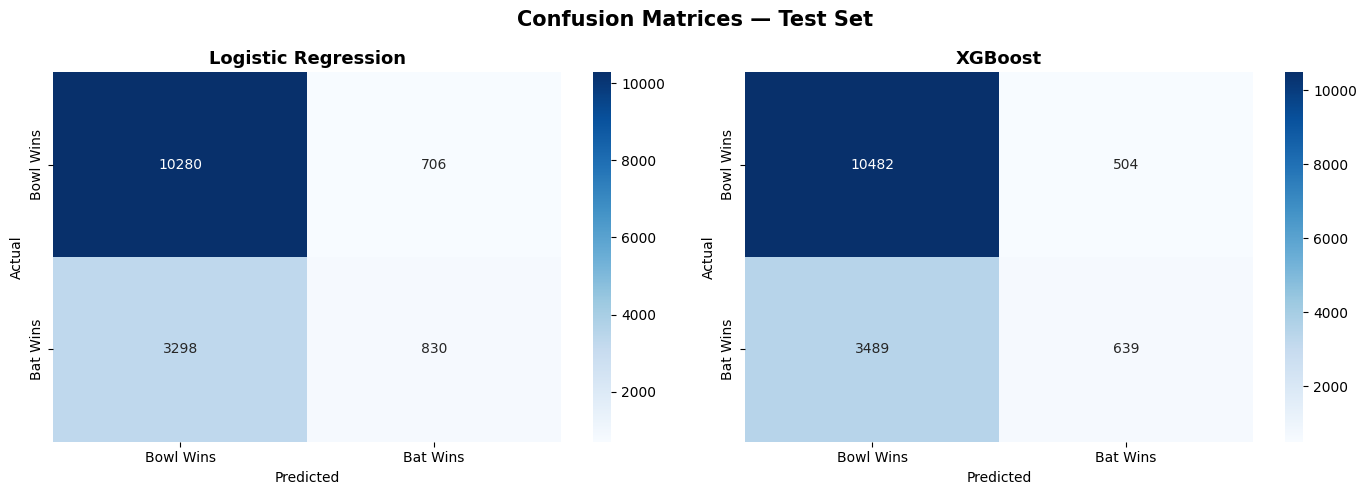

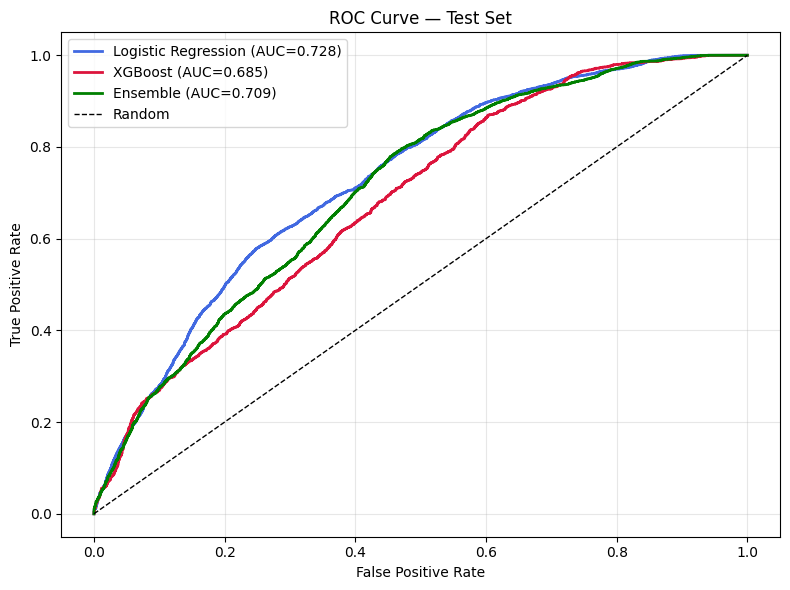

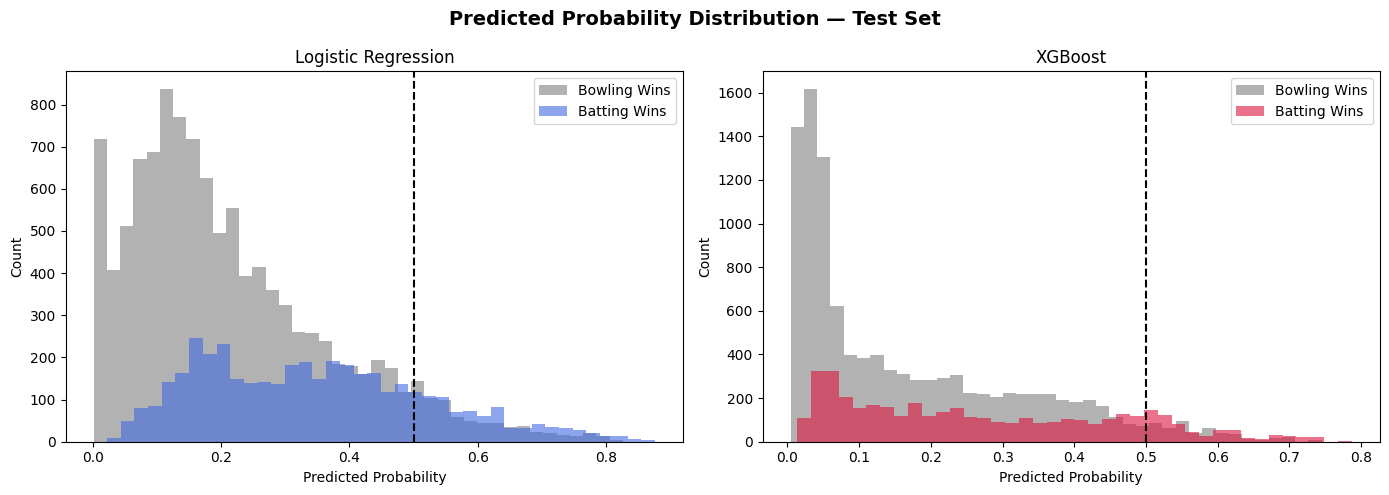

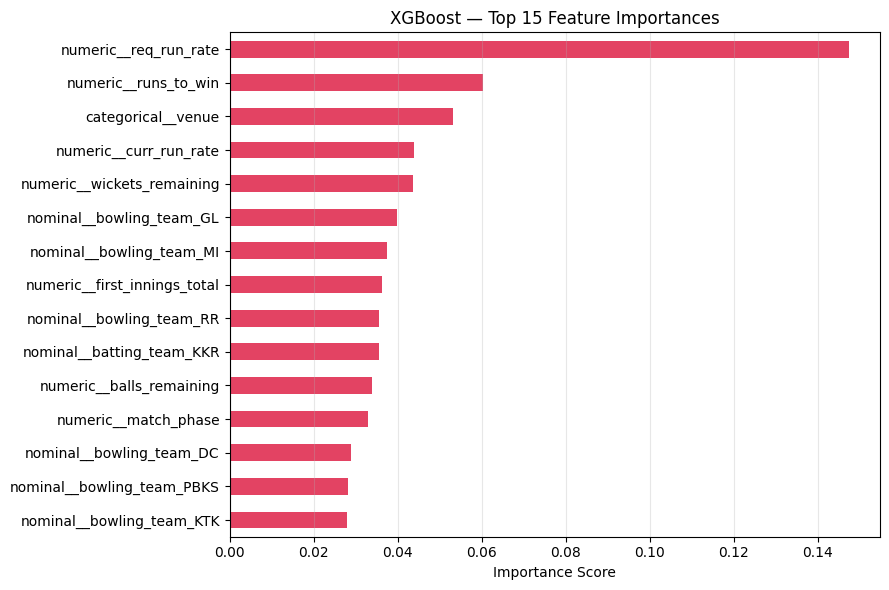

In [837]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrices — Test Set', fontsize=15, fontweight='bold')
for ax, preds, title in zip(axes,
                             [lr_test_pred, xgb_test_pred],
                             ['Logistic Regression', 'XGBoost']):
    sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt='d',
                cmap='Blues', ax=ax,
                xticklabels=['Bowl Wins', 'Bat Wins'],
                yticklabels=['Bowl Wins', 'Bat Wins'])
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')
plt.tight_layout(); plt.show()

# — ROC Curves —
fig, ax = plt.subplots(figsize=(8, 6))
for probs, name, color in [
    (lr_test_prob,  'Logistic Regression', 'royalblue'),
    (xgb_test_prob, 'XGBoost',             'crimson'),
    (ens_test_prob, 'Ensemble',            'green'),
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    ax.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test, probs):.3f})',
            color=color, lw=2)
ax.plot([0,1],[0,1],'k--',lw=1,label='Random')
ax.set(xlabel='False Positive Rate', ylabel='True Positive Rate',
       title='ROC Curve — Test Set')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# — Probability Distributions —
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Predicted Probability Distribution — Test Set', fontsize=14, fontweight='bold')
for ax, probs, title, color in zip(axes,
                                    [lr_test_prob, xgb_test_prob],
                                    ['Logistic Regression', 'XGBoost'],
                                    ['royalblue', 'crimson']):
    ax.hist(probs[y_test==0], bins=40, alpha=0.6, label='Bowling Wins', color='gray')
    ax.hist(probs[y_test==1], bins=40, alpha=0.6, label='Batting Wins', color=color)
    ax.axvline(0.5, color='black', linestyle='--', lw=1.5)
    ax.set(title=title, xlabel='Predicted Probability', ylabel='Count')
    ax.legend()
plt.tight_layout(); plt.show()

# — XGB Feature Importance —
feature_names = xgb_pipe.named_steps['columntransformer'].get_feature_names_out()
importance = (pd.Series(xgb_pipe.named_steps['xgbclassifier'].feature_importances_,
                        index=feature_names)
                .sort_values()
                .tail(15))
fig, ax = plt.subplots(figsize=(9, 6))
importance.plot(kind='barh', ax=ax, color='crimson', alpha=0.8)
ax.set(title='XGBoost — Top 15 Feature Importances', xlabel='Importance Score')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

In [838]:

'''
row = pd.DataFrame([{
    'batting_team': 'GT',
    'bowling_team': 'RR',
    'runs_to_win': 105,
    'curr_run_rate': round(82 / (61/6), 2),   # 8.07
    'req_run_rate': round(105 / (59/6), 2),    # 10.68
    'crr_rrr_ratio': round((82 / (61/6)) / (105 / (59/6)), 2),  # 0.76,
    'balls_remaining': 59,
    'wickets_remaining':9 , #ONLY 1 OUT
    # 'batting_average': 28,
    # 'career_strike_rate': 140,
    # 'exp_bowler_eco': 7.2,
    # 'exp_bowler_avg': 26,
    'pressure':  round((105 / (59/6)) / (82 / (61/6)), 2),
    'first_innings_total':186,
    'match_phase':1,
    "venue":"narendra_modi_stadium"
}])


[0]
[[0.6575856 0.3424144]]
RR will win the match



row = pd.DataFrame([{
    'batting_team': 'GT',
    'bowling_team': 'RR',
    'runs_to_win': 78,
    'curr_run_rate': round(100 / (79/6), 2),      # 7.59
    'req_run_rate': round(78 / (41/6), 2),         # 11.41
    'crr_rrr_ratio': round((100/(79/6)) / (78/(41/6)), 2),  # 0.67
    'balls_remaining': 41,
    'wickets_remaining': 5,
    'pressure': round((78/(41/6)) / (100/(79/6)), 2),  # 1.50
    'first_innings_total': 177,
    'match_phase': 1,   # over 13 → middle (5-14)
    "venue": "narendra_modi_stadium"
}])

pred_lr = pipe.predict(row)
pred_lr_proba=pipe.predict_proba(row)
print(pred_lr)
print(pred_lr_proba)
if pred_lr == 1:
  print(row['batting_team'].values[0], "will win the match")
else:
  print(row['bowling_team'].values[0], 'will win the match')


[0]
[[0.83415954 0.16584046]]
RR will win the match

row = pd.DataFrame([{
    'batting_team': 'GT',
    'bowling_team': 'RR',
    'runs_to_win': 34,
    'curr_run_rate': round(144 / (99/6), 2),            # 8.73
    'req_run_rate': round(34 / (21/6), 2),               # 9.71
    'crr_rrr_ratio': round((144/(99/6)) / (34/(21/6)), 2),   # 0.90
    'balls_remaining': 21,
    'wickets_remaining': 7,
    'pressure': round((34/(21/6)) / (144/(99/6)), 2),    # 1.11
    'first_innings_total': 177,
    'match_phase': 2,   # over 16 → death
    "venue": "narendra_modi_stadium"
}])

pred_lr = pipe.predict(row)
pred_lr_proba=pipe.predict_proba(row)
print(pred_lr)
print(pred_lr_proba)
if pred_lr == 1:
  print(row['batting_team'].values[0], "will win the match")
else:
  print(row['bowling_team'].values[0], 'will win the match')


[0]
[[0.58845044 0.41154956]]
RR will win the match

'''

'\nrow = pd.DataFrame([{\n    \'batting_team\': \'GT\',\n    \'bowling_team\': \'RR\',\n    \'runs_to_win\': 105,\n    \'curr_run_rate\': round(82 / (61/6), 2),   # 8.07\n    \'req_run_rate\': round(105 / (59/6), 2),    # 10.68\n    \'crr_rrr_ratio\': round((82 / (61/6)) / (105 / (59/6)), 2),  # 0.76,\n    \'balls_remaining\': 59,\n    \'wickets_remaining\':9 , #ONLY 1 OUT\n    # \'batting_average\': 28,\n    # \'career_strike_rate\': 140,\n    # \'exp_bowler_eco\': 7.2,\n    # \'exp_bowler_avg\': 26,\n    \'pressure\':  round((105 / (59/6)) / (82 / (61/6)), 2),\n    \'first_innings_total\':186,\n    \'match_phase\':1,\n    "venue":"narendra_modi_stadium"\n}])\n\n\n[0]\n[[0.6575856 0.3424144]]\nRR will win the match\n\n\n\nrow = pd.DataFrame([{\n    \'batting_team\': \'GT\',\n    \'bowling_team\': \'RR\',\n    \'runs_to_win\': 78,\n    \'curr_run_rate\': round(100 / (79/6), 2),      # 7.59\n    \'req_run_rate\': round(78 / (41/6), 2),         # 11.41\n    \'crr_rrr_ratio\': round((100/